In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPRegressor


In [5]:
data = pd.read_csv("energy_data.csv")
data.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [6]:
data.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1000.000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25462.388,48.372000,25.606000,22.611390,4166.252570
std,14294.554,29.061972,14.105166,7.139943,933.313064
min,560.000,1.000000,1.000000,10.050000,1683.950000
25%,13169.750,22.000000,13.000000,16.475000,3509.482500
50%,25477.000,47.000000,26.000000,22.815000,4175.730000
75%,37446.250,73.250000,38.000000,28.850000,4863.850000
max,49997.000,99.000000,49.000000,34.990000,6530.600000


In [ ]:
data.groupby("Building Type")["Energy Consumption"].sum()


Building Type
Commercial     1387687.92
Industrial     1501040.21
Residential    1277524.44
Name: Energy Consumption, dtype: float64

In [11]:
data.groupby("Number of Occupants")["Energy Consumption"].mean()


Number of Occupants
1     3918.034444
2     3718.550000
3     3611.071429
4     3711.408333
5     3970.505000
         ...     
95    4445.703750
96    4589.386000
97    4644.497778
98    4935.403846
99    5163.093077
Name: Energy Consumption, Length: 99, dtype: float64

In [10]:
data.isnull().sum()
data = data.fillna(method="ffill")

C:\Users\Мерей\AppData\Local\Temp\ipykernel_25716\2485041513.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="ffill")


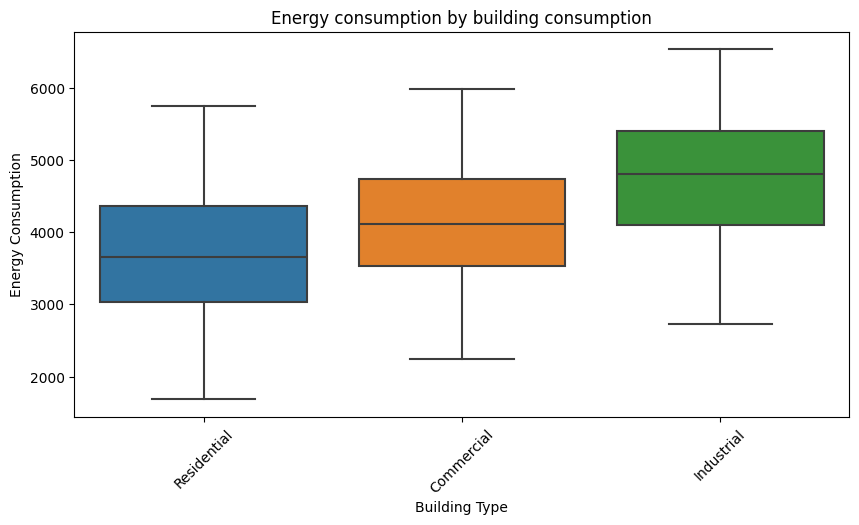

In [21]:
plt.figure(figsize=(10,5))
sns.boxplot(data=data, x="Building Type", y="Energy Consumption")
plt.title("Energy consumption by building consumption")
plt.xticks(rotation=45)
plt.show()

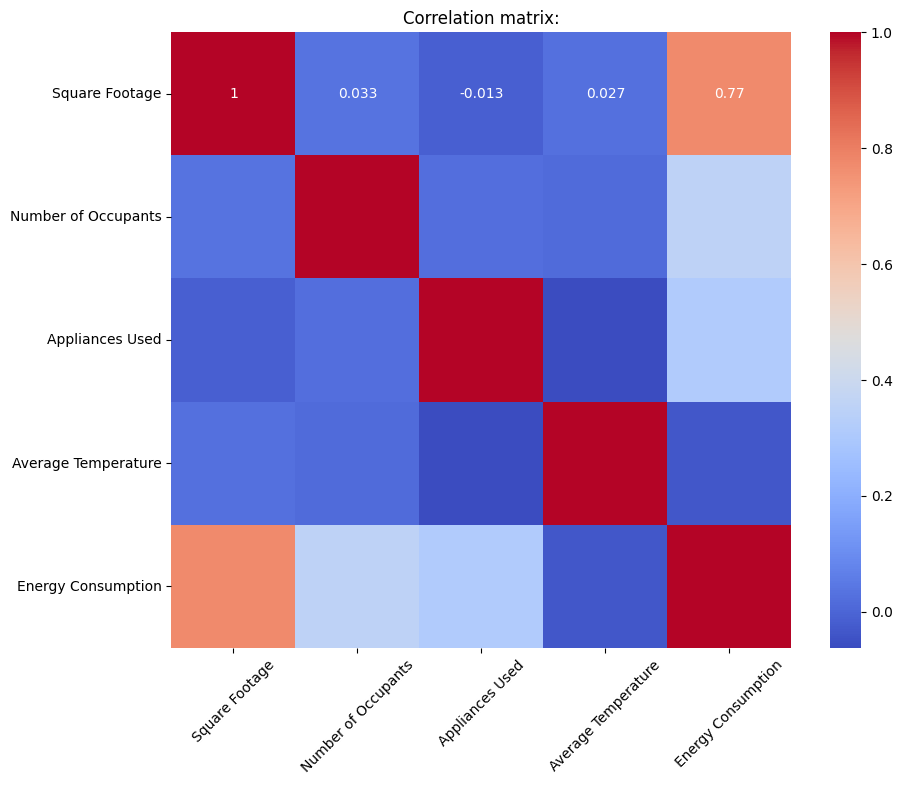

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(data[['Square Footage','Number of Occupants', 'Appliances Used', 'Average Temperature', 'Energy Consumption']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation matrix:")
plt.xticks(rotation=45)
plt.show()

In [26]:
X = data[['Square Footage', 'Number of Occupants', 'Average Temperature', 'Energy Consumption']]
y = data[['Energy Consumption']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred=model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


MSE: 1.225643853377478e-22
R2: 1.0
Coefficients: [[7.86323916e-16 2.22044605e-16 2.35146260e-15 1.00000000e+00]]
Intercept: [-2.09183781e-11]


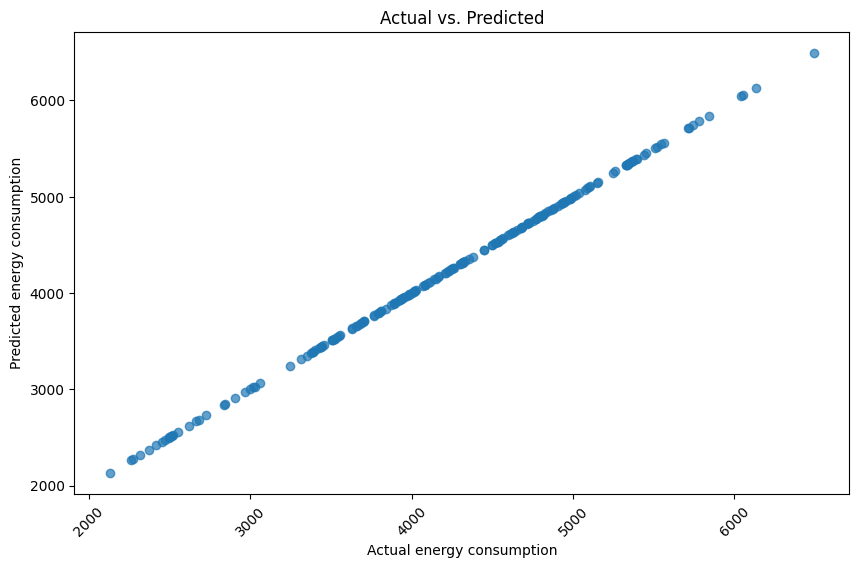

In [29]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual energy consumption")
plt.ylabel("Predicted energy consumption")
plt.title("Actual vs. Predicted")
plt.xticks(rotation=45)
plt.show()


In [31]:
mlp = MLPRegressor(hidden_layer_sizes=(64,32), activation='relu', solver='adam', max_iter=500, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
print("MLP MSE:", mean_squared_error(y_test, y_pred_mlp))
print("MLP R2:", r2_score(y_test, y_pred_mlp))

c:\Users\Мерей\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1775: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MLP MSE: 22.421589250823732
MLP R2: 0.9999724652083531
